# Trabajo Práctico 4 — Aprendizaje No-Supervisado
## Ejercicio 1: Inspección de los datos

---

**Dataset:**   
**Objetivo:** Explorar la naturaleza del dataset.

In [70]:
import numpy as np
import pandas as pd

# Enable autoreload for automatic updates of imported modules
%load_ext autoreload
%autoreload 2

# Add src folder to path
import sys, os
ruta_src = os.path.abspath("src")
sys.path.append(ruta_src)

import utils, data_splitting, models, trainer, metrics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import torch
print(sys.executable)
print(torch.__version__)
print(torch.cuda.is_available())

c:\Users\pazbi\OneDrive\Escritorio\ml\ml_tp4\torch_env\Scripts\python.exe
2.12.0+cpu
False


In [3]:
np.random.seed(42)

In [4]:
# load data frame
df = pd.read_csv('data/raw/fashion_mnist_subset.csv')

In [5]:
# separate features and label
y = df["label"].values
X = df.drop("label", axis=1).values

In [6]:
# dataset summary 
summary_data, summary_labels = utils.dataset_summary(X, y)

In [7]:
display(summary_data)

,Métrica,Valor
0,Samples,"25,000"
1,Features,784 (28x28 px)
2,Classes,10
3,Pixel range,"[0.0, 1.0]"
4,Dtype,float64
5,NaN values,0
6,Balance,uniform


In [8]:
display(summary_labels)

,Class ID,Name,Count,Pct (%)
0,0,T-shirt/top,2500,10.0
1,1,Trouser,2500,10.0
2,2,Pullover,2500,10.0
3,3,Dress,2500,10.0
4,4,Coat,2500,10.0
5,5,Sandal,2500,10.0
6,6,Shirt,2500,10.0
7,7,Sneaker,2500,10.0
8,8,Bag,2500,10.0
9,9,Ankle boot,2500,10.0


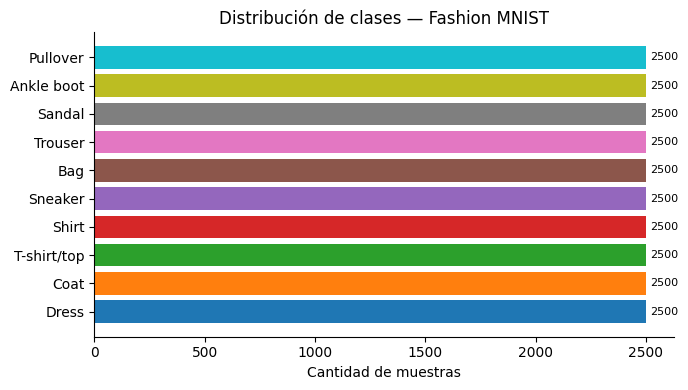

In [9]:
# show classes proportions
utils.show_proportions(df)

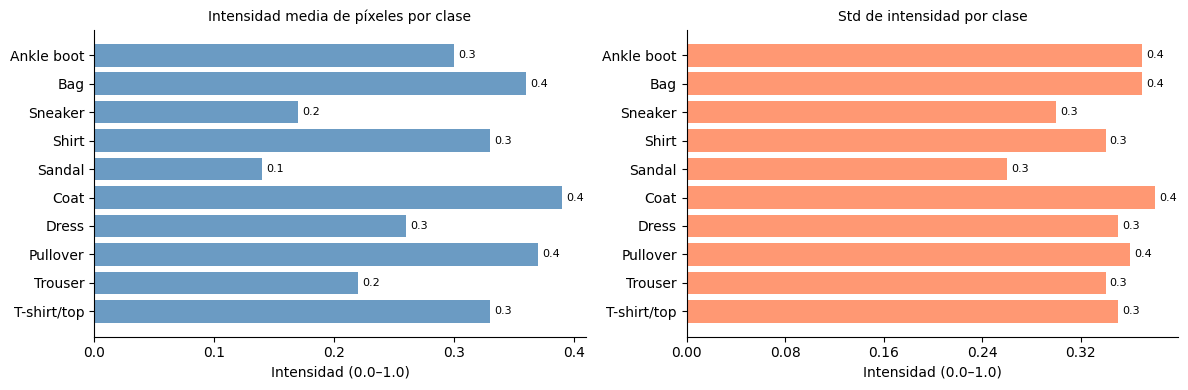

,class,mean_px,std_px
0,T-shirt/top,0.33,0.35
1,Trouser,0.22,0.34
2,Pullover,0.37,0.36
3,Dress,0.26,0.35
4,Coat,0.39,0.38
5,Sandal,0.14,0.26
6,Shirt,0.33,0.34
7,Sneaker,0.17,0.30
8,Bag,0.36,0.37
9,Ankle boot,0.30,0.37


In [10]:
pixel_stats = utils.analyze_pixels(X, y)
display(pixel_stats)

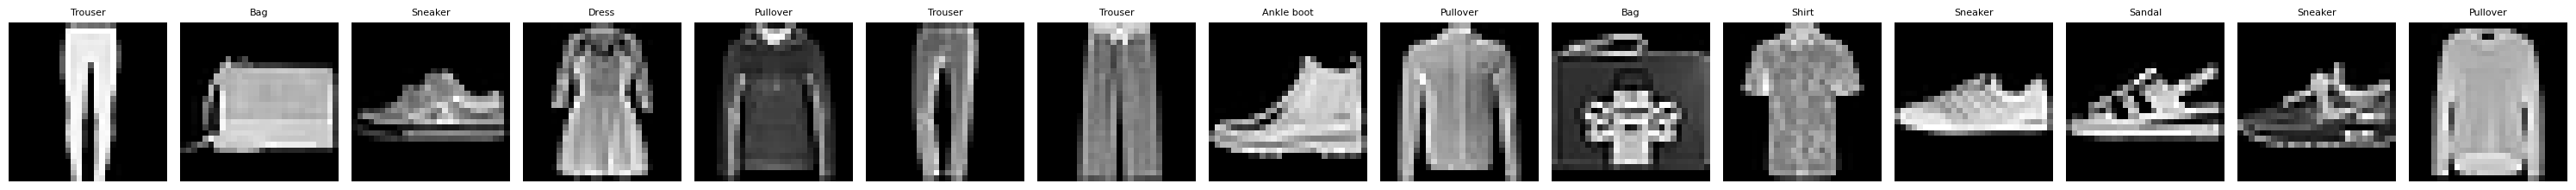

In [11]:
# show 15 random items
idx = utils.show_images(X, y, 15)

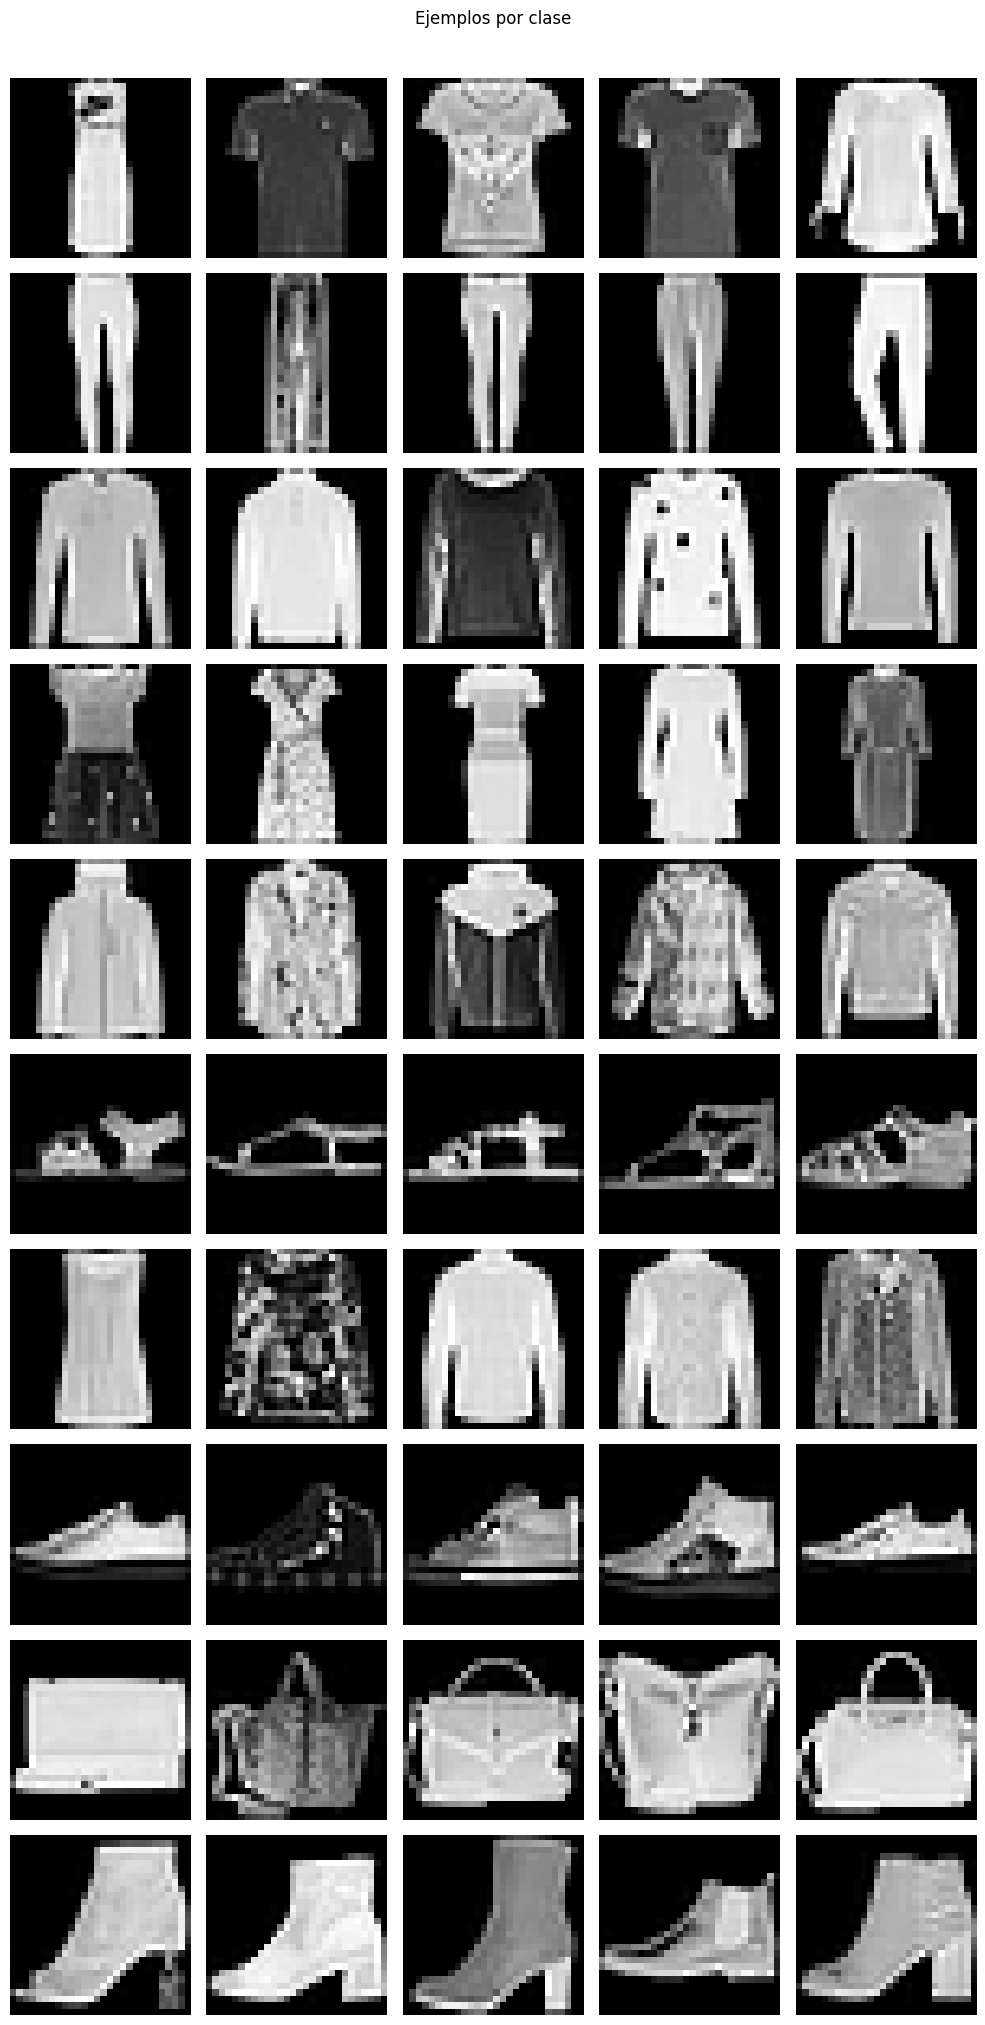

In [12]:
# show 5 items per class
utils.show_separate_classes(X, y, np.unique(y), 5)

In [13]:
# split data
train, test = data_splitting.random_stratified_split(df)

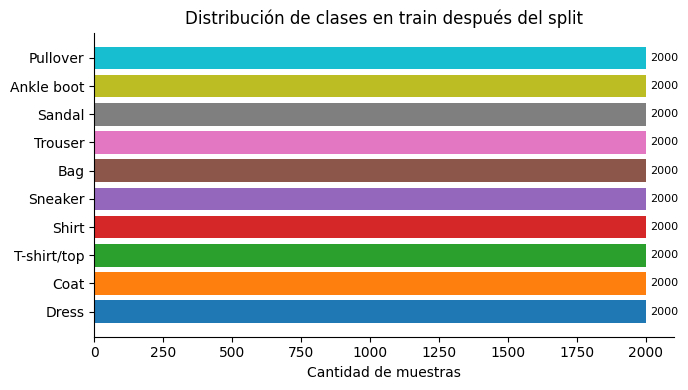

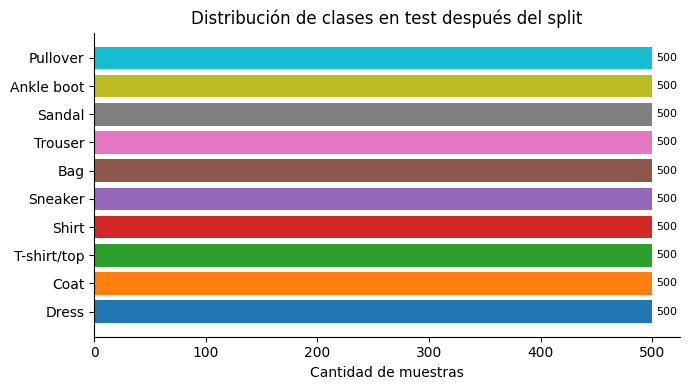

In [14]:
utils.show_proportions(train, title="Distribución de clases en train después del split")
utils.show_proportions(test, title="Distribución de clases en test después del split")

In [15]:
# separate features and label
y_train = train["label"].values
X_train = train.drop("label", axis=1)
y_test = test["label"].values
X_test = test.drop("label", axis=1)

## Ejercicio 2: Reducción de dimensionalidad

---

**Dataset:**   
**Objetivo:**

In [19]:
pca_full = models.PCA(k_components=X_train.shape[1])

# Train
X_train_std = pca_full.fit_transform_scaler(X_train)
Z_train = pca_full.fit_transform_pca(X_train)
# Test
X_test_std = pca_full.transform_scaler(X_test)
Z_test = pca_full.transform_pca(X_test)

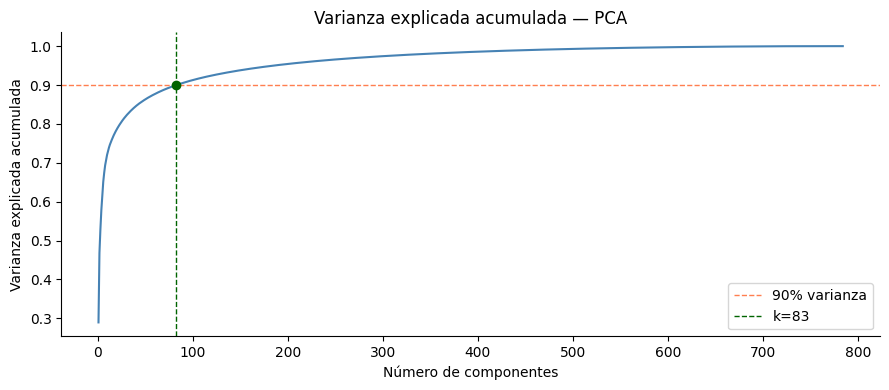

In [20]:
k_opt = utils.plot_explained_variance(pca_full)

In [ ]:
pca_k = models.PCA(k_components=k_opt)

# Train
X_train_std_k = pca_k.fit_transform_scaler(X_train)
Z_train_k = pca_k.fit_transform_pca(X_train)
train_hat_k = pca_k.reconstruct_x_hat(Z_train_k)

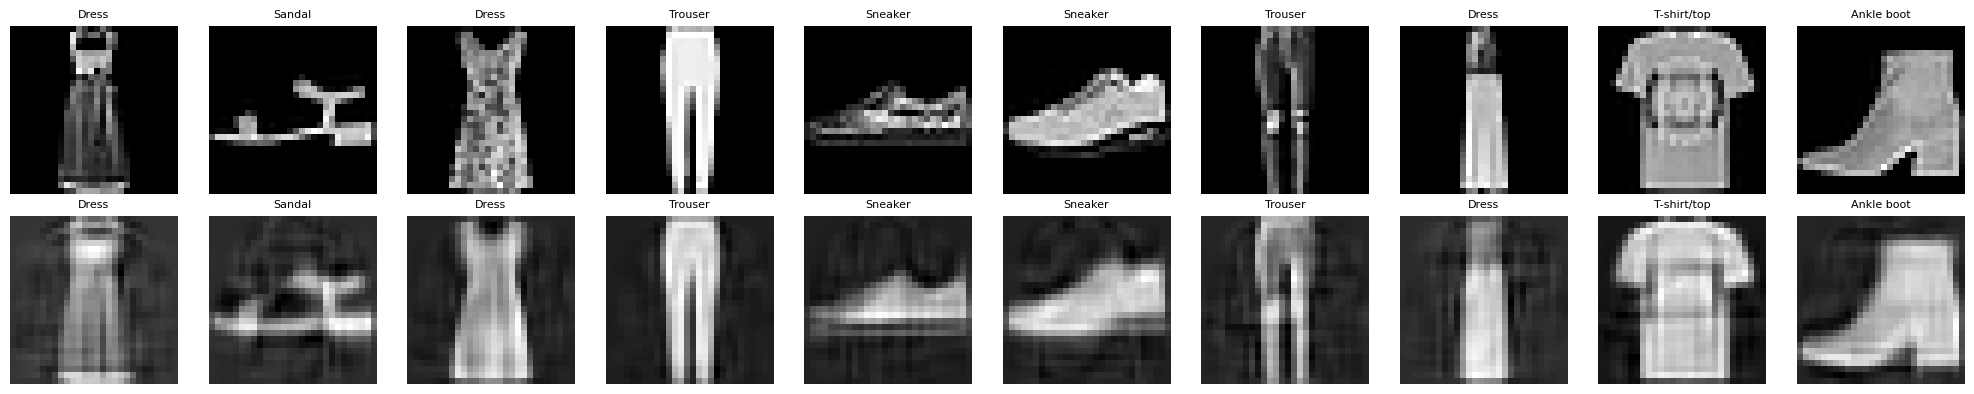

In [ ]:
utils.plot_reconstruction(X_train.values, train_hat_k, y_train)

In [35]:
INPUT_DIM = X_train.shape[1]
LATENT_DIM = k_opt
batch_size = 256
device = device = ("cuda" if torch.cuda.is_available() else "cpu")
train_loader = trainer.make_loader(X_train, batch_size=batch_size, shuffle=True)
test_loader = trainer.make_loader(X_test,  batch_size=batch_size, shuffle=False)

Epoch  10/50  train=0.0190  test=0.0191
Epoch  20/50  train=0.0150  test=0.0152
Epoch  30/50  train=0.0131  test=0.0136
Epoch  40/50  train=0.0121  test=0.0128
Epoch  50/50  train=0.0119  test=0.0127


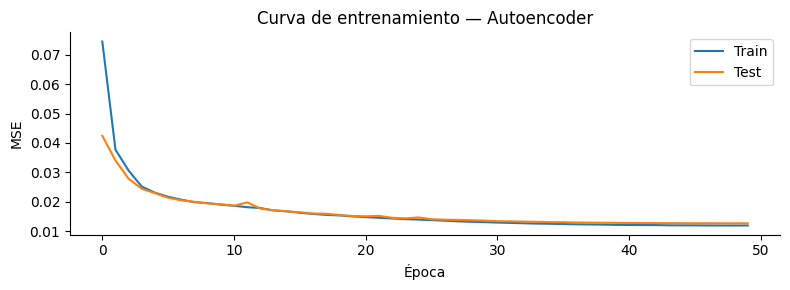

In [36]:
ae = models.AE(input_dim=INPUT_DIM, latent_dim=LATENT_DIM).to(device)
train_losses, test_losses = trainer.train_AE(ae, train_loader=train_loader, test_loader=test_loader, device=device, epochs=50)
utils.plot_loss(train_losses, test_losses)

In [37]:
# Test PCA Reconsruction
X_test_std_k = pca_k.fit_transform_scaler(X_test)
Z_test_k = pca_k.fit_transform_pca(X_test)
test_hat_k = pca_k.reconstruct_x_hat(Z_test_k)

# Test AE Reconstruction
X_hat_ae = trainer.reconstruct_AE(ae, X_test, device)

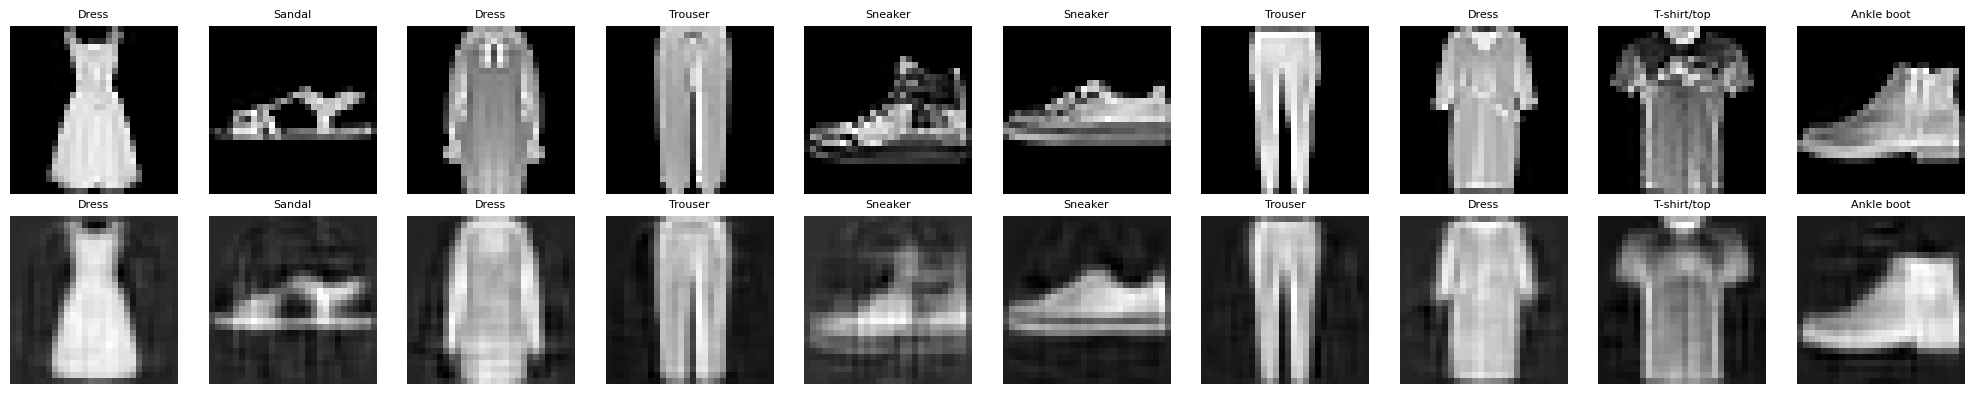

In [38]:
utils.plot_reconstruction(X_test.values, test_hat_k, y_test)

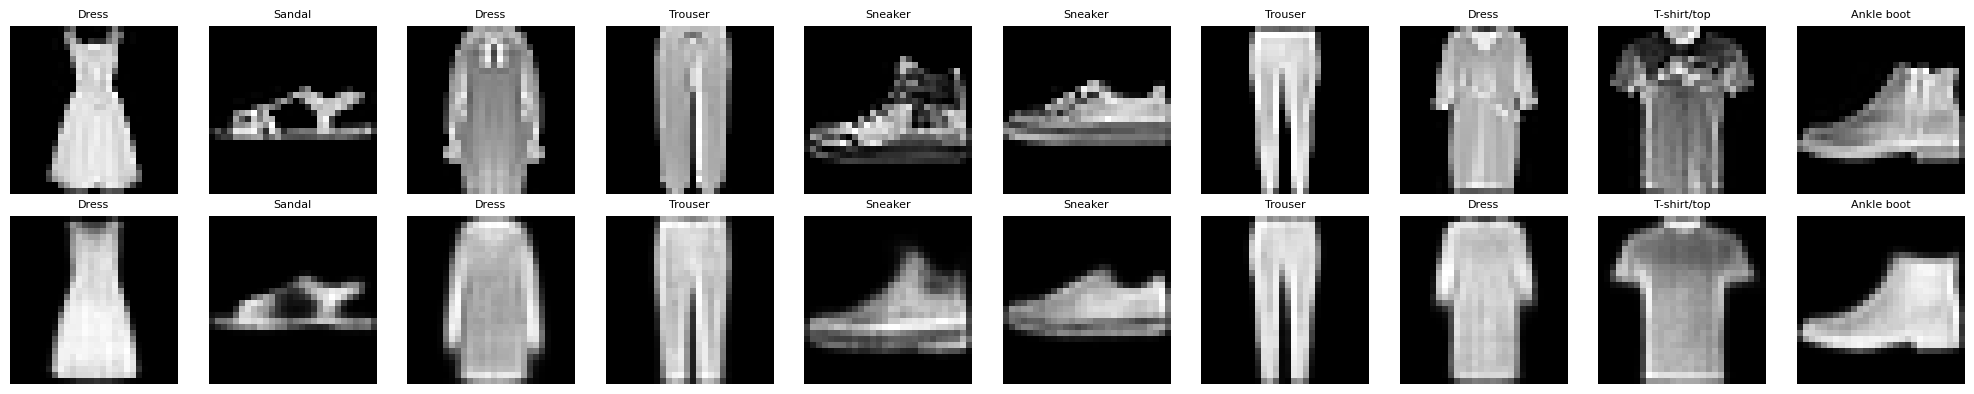

In [40]:
utils.plot_reconstruction(X_test.values, X_hat_ae, y_test)

In [42]:
Z_train_ae = trainer.encode_dataset(ae, X_train, device)
Z_test_ae = trainer.encode_dataset(ae, X_test, device)
Z_train_pca = pca_k.transform_pca(X_train)
Z_test_pca  = pca_k.transform_pca(X_test)

## Ejercicio 3: Clustering

---

**Dataset:**   
**Objetivo:**

In [63]:
X_sample, y_sample = data_splitting.stratified_sample(Z_train_pca, y_train, n=3000)
X_sample_ae, y_sample = data_splitting.stratified_sample(Z_train_ae, y_train, n=3000)
K_RANGE = range(5, 16)
N_SEEDS = 5

In [64]:
# mismos índices para comparación justa — mejor así:
idx_sample = np.random.default_rng(42).choice(len(Z_train_pca), size=3000, replace=False)
X_sample_pca = Z_train_pca[idx_sample]
X_sample_ae = Z_train_ae[idx_sample]
y_sample = y_train[idx_sample]

In [69]:
results_km_pca  = {}
results_km_ae   = {}
results_gmm_pca = {}
results_gmm_ae  = {}

for k in K_RANGE:
    # ── KMeans: múltiples seeds, mejor por inercia ────────────
    best_km_pca, best_km_ae = None, None
    best_i_pca = best_i_ae  = np.inf

    for seed in range(N_SEEDS):
        m_pca = models.KMeans(k=k).fit(X_sample_pca, seed=seed)
        if m_pca.inertia < best_i_pca:
            best_i_pca, best_km_pca = m_pca.inertia, m_pca

        m_ae = models.KMeans(k=k).fit(X_sample_ae, seed=seed)
        if m_ae.inertia < best_i_ae:
            best_i_ae, best_km_ae = m_ae.inertia, m_ae

    results_km_pca[k] = best_km_pca
    results_km_ae[k] = best_km_ae

    # ── GMM: una sola corrida, inicializada con el mejor KMeans ─
    # determinista → no necesita loop de seeds
    results_gmm_pca[k] = models.GMM(k=k).fit(X_sample_pca, km=best_km_pca)
    results_gmm_ae[k] = models.GMM(k=k).fit(X_sample_ae,  km=best_km_ae)

    print(f"k={k:2d}  inercia_pca={best_i_pca:.2f}  inercia_ae={best_i_ae:.2f}"
          f"  ll_pca={results_gmm_pca[k].log_likelihoods[-1]:.2f}"
          f"  ll_ae={results_gmm_ae[k].log_likelihoods[-1]:.2f}")

  GMM k=5: convergió en iteración 35
  GMM k=5: convergió en iteración 33
k= 5  inercia_pca=95491.72  inercia_ae=136847.28  ll_pca=-130274.22  ll_ae=-254545.61
  GMM k=6: convergió en iteración 46
  GMM k=6: convergió en iteración 32
k= 6  inercia_pca=88369.76  inercia_ae=128680.27  ll_pca=-128738.65  ll_ae=-243173.48
  GMM k=7: convergió en iteración 58
k= 7  inercia_pca=83947.65  inercia_ae=121534.39  ll_pca=-126392.97  ll_ae=-236269.40
  GMM k=8: convergió en iteración 60
k= 8  inercia_pca=80103.66  inercia_ae=113717.91  ll_pca=-124958.88  ll_ae=-227984.88
  GMM k=9: convergió en iteración 75
k= 9  inercia_pca=76507.53  inercia_ae=107140.00  ll_pca=-123275.63  ll_ae=-223607.72
  GMM k=10: convergió en iteración 74
k=10  inercia_pca=73469.66  inercia_ae=103475.85  ll_pca=-122554.33  ll_ae=-219373.38
  GMM k=11: convergió en iteración 98
  GMM k=11: convergió en iteración 83
k=11  inercia_pca=70865.16  inercia_ae=98062.42  ll_pca=-120864.74  ll_ae=-212174.38
  GMM k=12: convergió en i

In [60]:
N_SEEDS_GMM = 3
results_gmm = {}

for k in K_RANGE:
    best_km = results_km[k]  # el mejor KMeans del item anterior
    model = models.GMM(k=k).fit(X_sample, km=best_km)
    results_gmm[k] = model
    print(f"k={k:2d}  log-likelihood={model.log_likelihoods[-1]:.2f}")

  GMM k=5: convergió en iteración 56
k= 5  log-likelihood=-131700.82
  GMM k=6: convergió en iteración 56
k= 6  log-likelihood=-129730.18
  GMM k=7: convergió en iteración 59
k= 7  log-likelihood=-127262.24
  GMM k=8: convergió en iteración 69
k= 8  log-likelihood=-125649.21
  GMM k=9: convergió en iteración 52
k= 9  log-likelihood=-124449.27
k=10  log-likelihood=-122790.50
k=11  log-likelihood=-121455.43
k=12  log-likelihood=-120616.38
  GMM k=13: convergió en iteración 93
k=13  log-likelihood=-119135.82
  GMM k=14: convergió en iteración 51
k=14  log-likelihood=-118825.10
k=15  log-likelihood=-117510.10


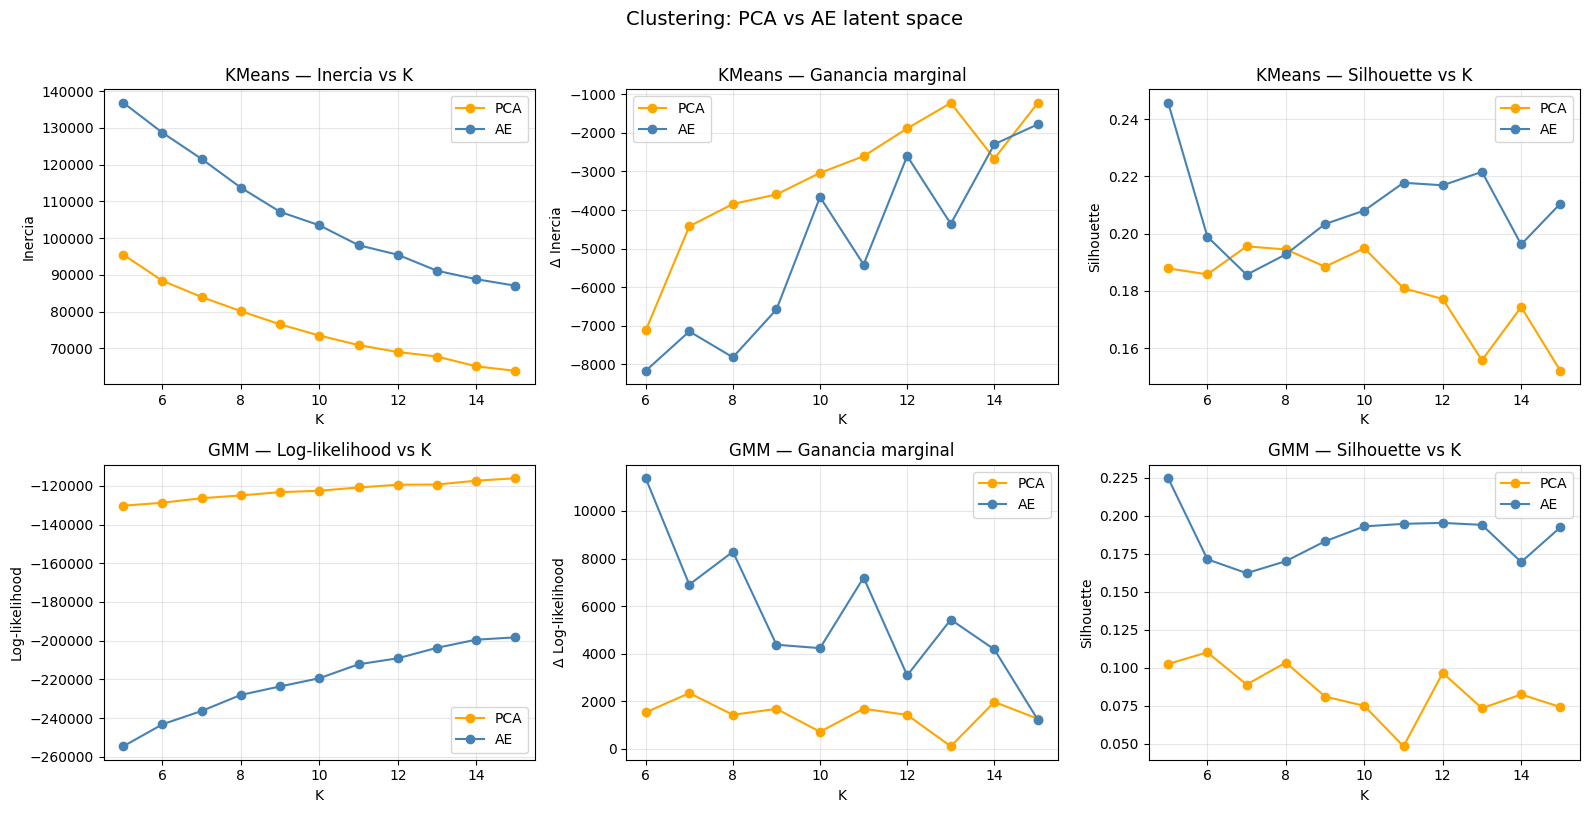

In [71]:
metrics_pca = metrics.compute_clustering_metrics(K_RANGE, results_km_pca, results_gmm_pca, X_sample_pca)
metrics_ae  = metrics.compute_clustering_metrics(K_RANGE, results_km_ae,  results_gmm_ae,  X_sample_ae)

utils.plot_clustering_metrics(metrics_pca, metrics_ae)

t-SNE sobre espacio PCA...
Calculando matriz P...
  iter  100  KL=14.4499
  iter  200  KL=14.6012
  iter  300  KL=1.3469
  iter  400  KL=1.0792
  iter  500  KL=1.0028
  iter  600  KL=0.9726
  iter  700  KL=0.9575
  iter  800  KL=0.9489
  iter  900  KL=0.9435
  iter 1000  KL=0.9396
t-SNE sobre espacio AE...
Calculando matriz P...
  iter  100  KL=14.4935
  iter  200  KL=14.7563
  iter  300  KL=1.3581
  iter  400  KL=1.1068
  iter  500  KL=1.0320
  iter  600  KL=1.0055
  iter  700  KL=0.9931
  iter  800  KL=0.9854
  iter  900  KL=0.9805
  iter 1000  KL=0.9771


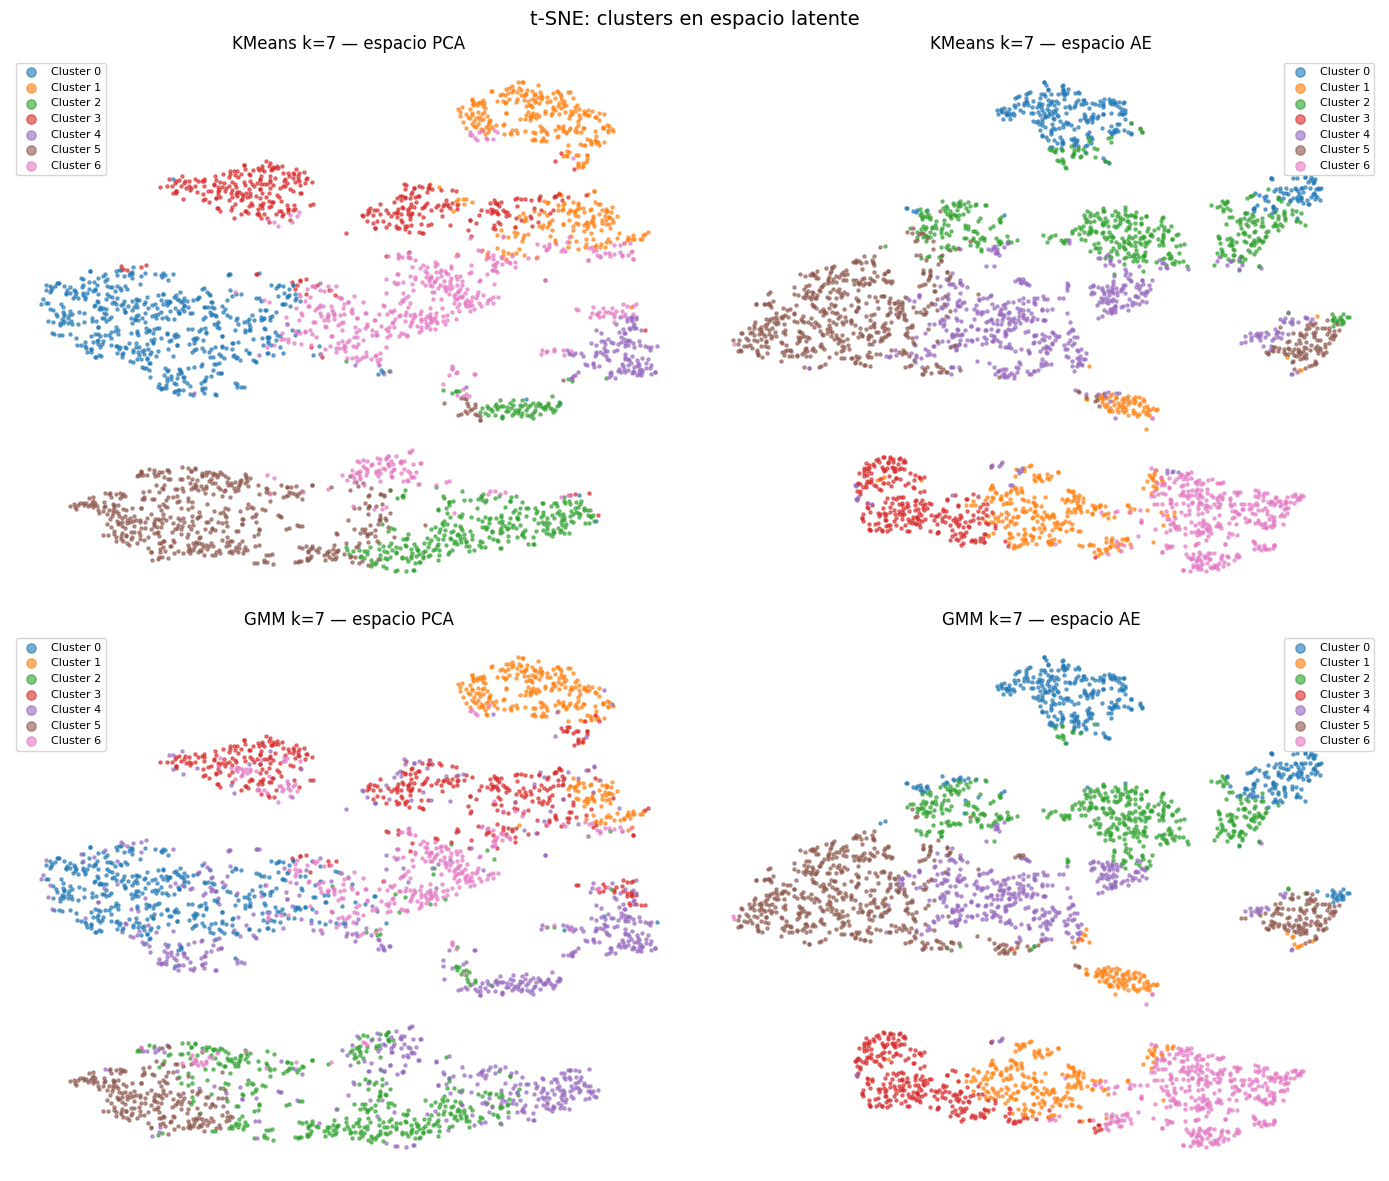

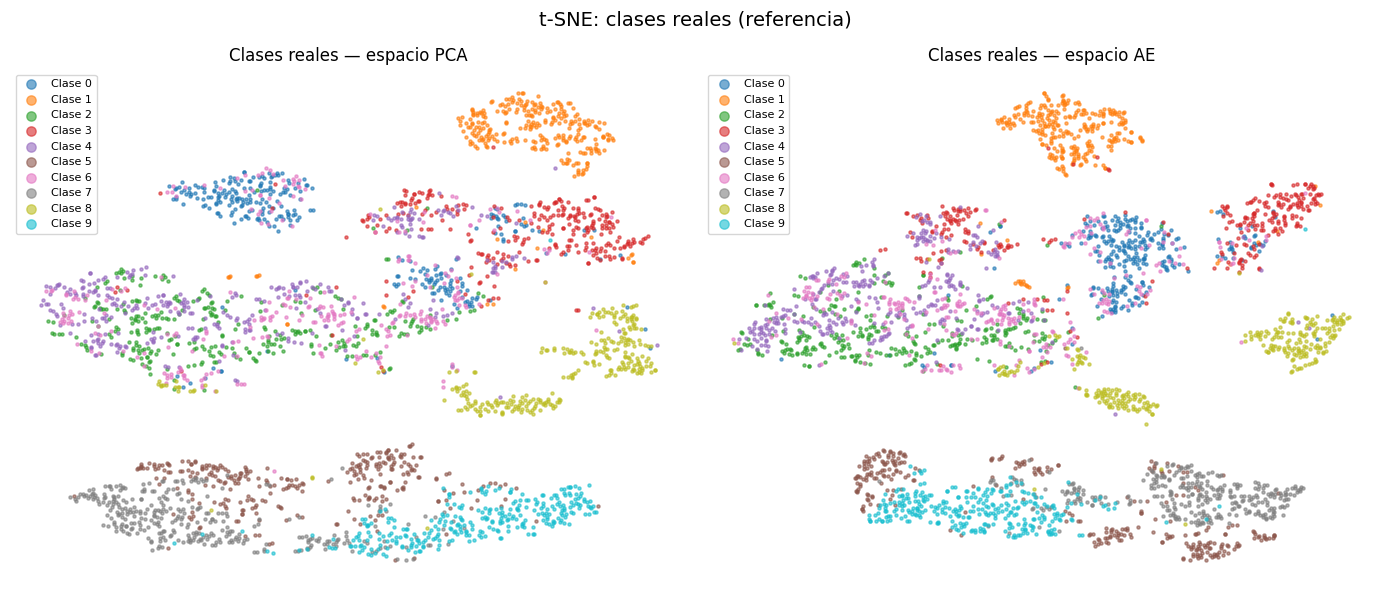

In [72]:
# ── Elegir K óptimo ───────────────────────────────────────────
K_OPT = 7

labels_km_pca  = results_km_pca[K_OPT].labels
labels_km_ae   = results_km_ae[K_OPT].labels
labels_gmm_pca = results_gmm_pca[K_OPT].predict(X_sample_pca)
labels_gmm_ae  = results_gmm_ae[K_OPT].predict(X_sample_ae)

# ── t-SNE sobre espacio PCA y AE ─────────────────────────────
# t-SNE es O(N²) — con 3000 puntos tarda ~5-10 min
print("t-SNE sobre espacio PCA...")
Y_pca = metrics.tsne(X_sample_pca, perplexity=30, n_iter=1000)

print("t-SNE sobre espacio AE...")
Y_ae  = metrics.tsne(X_sample_ae,  perplexity=30, n_iter=1000)

metrics.plot_tsne_clusters(Y_pca, Y_ae,
                   labels_km_pca, labels_km_ae,
                   labels_gmm_pca, labels_gmm_ae,
                   k=K_OPT)

metrics.plot_tsne_true_labels(Y_pca, Y_ae, y_sample)

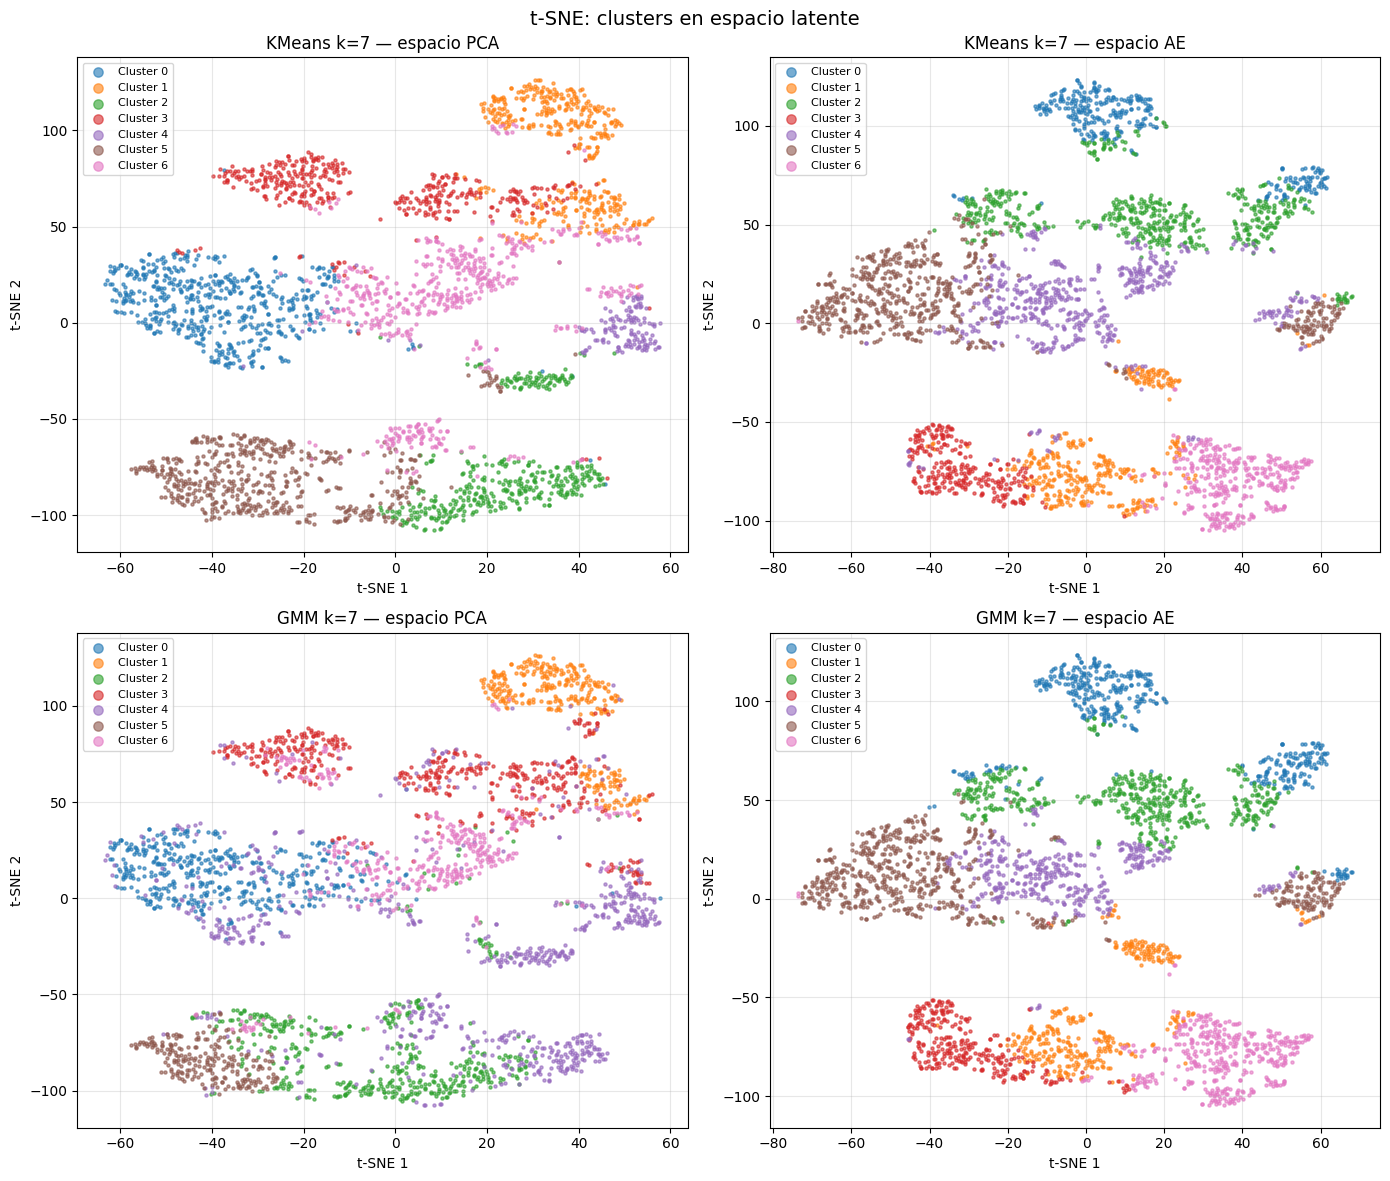

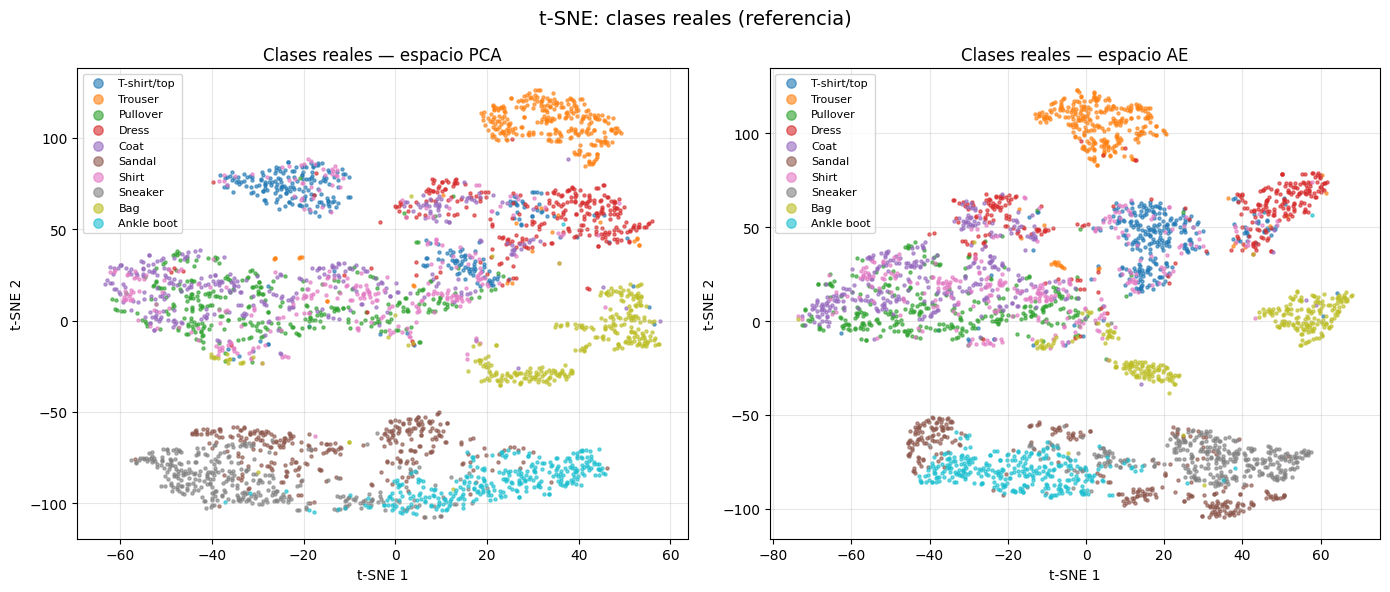

In [75]:
metrics.plot_tsne_clusters(Y_pca, Y_ae,
                   labels_km_pca, labels_km_ae,
                   labels_gmm_pca, labels_gmm_ae,
                   k=K_OPT)

metrics.plot_tsne_true_labels(Y_pca, Y_ae, y_sample)